<a href="https://colab.research.google.com/github/ArthurCBx/Applied_MachineLearning_in_Python/blob/main/Module2/Supervised_ML_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/ArthurCBx/Applied_MachineLearning_in_Python.git

Cloning into 'Applied_MachineLearning_in_Python'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 35 (delta 3), reused 23 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (35/35), 10.22 MiB | 11.72 MiB/s, done.
Resolving deltas: 100% (3/3), done.


# Introduction to Supervised ML

## Review
1. Feature Representation: Taking an object and converting into numbers that the computer can understand;
2. Data instances/samples/examples (X): One specific data from the dataset that contains all features;
3. Target Value (y): the label or continuos value that the data represent;
4. Training and test sets: portions of the dataset;
5. Model/Estimator:
   - Model fitting produces a 'trained model';
   - Training is the process of estimating model parameters.
6. Evaluation method

## Classification and Regression
- Both take a set of training instances and learn mapping to a target value;
- For classification, the target value is a discrete class value;
- For regression, the target value is continuous (floating point/real-valued);
- Looking at the target value's type will guide you on what supervised learning method to use;
- Many supervised learning methods have 'flavors' for both classification and regression.

## Supervised learning methods: Overview
- To start withm we'll look at 2 simple but powerful prediction algorithms: K-nearest neighbors and Linear model fit using least-squares
- These represent 1 complementary approaches to supervisied learning:
  - K-nearest neighbors makes few assumptions about the structure of the data and gives potentially accurate but sometimes unstable predictions (sensitive to small changes in the training data)
  - Linear models make strong assumptions about the structure of the data and give stable but potentially inaccurate predictions

# Generalization, Overfitting and Underfitting

- Generalization hability refers to an algorithm's ability to give accurate predictions for new, previously unseen data;
- Assumptions:
  - Future unseen data (test set) will have the same properties as the current training sets;
  - Thus, models that are accurate on the trainig set are expected to be accurate on the test set;
  - But that may not happen if the trained model is tuned too specifically to the training set.

- Models that are too complex for the amount of training data available are said to overfit and are not likely to generalize well to new examples;
- Models that are too simple, that don't even do well on the training data, are said to underfit and also not likely to generalize well.

# Supervised Learning: Datasets

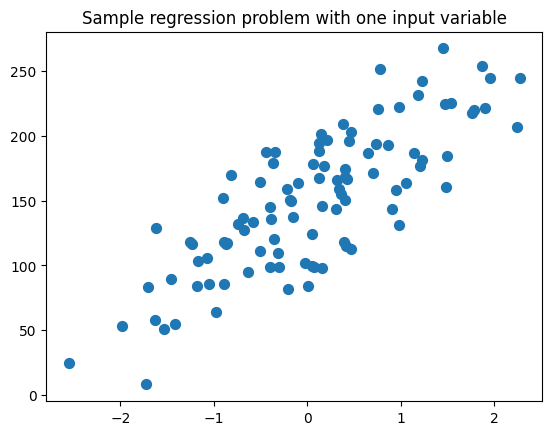

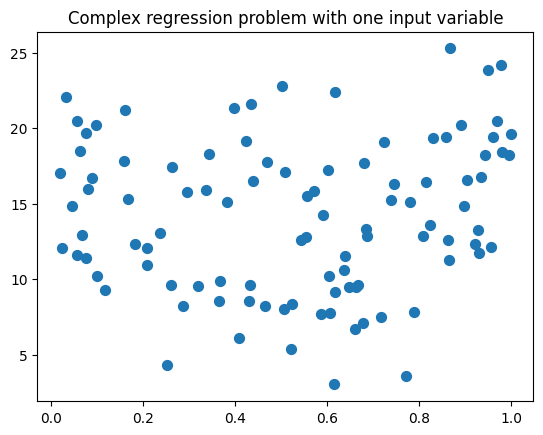

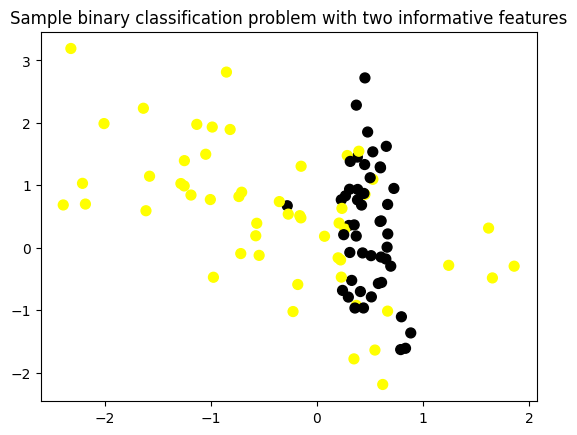

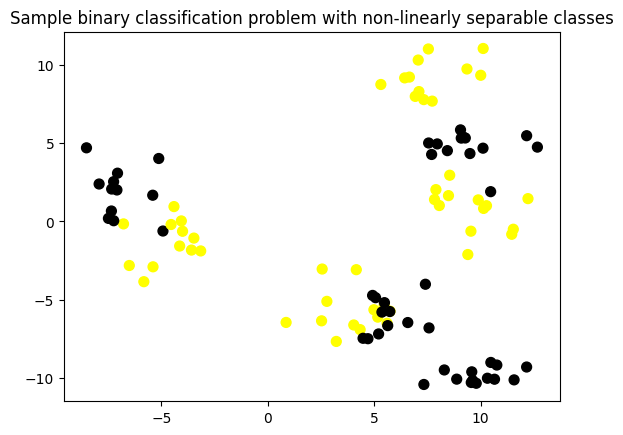

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification, make_blobs
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import load_crime_dataset

cmap_bold = ListedColormap(['#FFFF00', '#00FF00', '#0000FF','#000000'])


# synthetic dataset for simple regression
from sklearn.datasets import make_regression
plt.figure()
plt.title('Sample regression problem with one input variable')
X_R1, y_R1 = make_regression(n_samples = 100, n_features=1,
                            n_informative=1, bias = 150.0,
                            noise = 30, random_state=0)
plt.scatter(X_R1, y_R1, marker= 'o', s=50)
plt.show()


# synthetic dataset for more complex regression
from sklearn.datasets import make_friedman1
plt.figure()
plt.title('Complex regression problem with one input variable')
X_F1, y_F1 = make_friedman1(n_samples = 100,
                           n_features = 7, random_state=0)

plt.scatter(X_F1[:, 2], y_F1, marker= 'o', s=50)
plt.show()

# synthetic dataset for classification (binary)
plt.figure()
plt.title('Sample binary classification problem with two informative features')
X_C2, y_C2 = make_classification(n_samples = 100, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)
plt.scatter(X_C2[:, 0], X_C2[:, 1], c=y_C2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()


# more difficult synthetic dataset for classification (binary)
# with classes that are not linearly separable
X_D2, y_D2 = make_blobs(n_samples = 100, n_features = 2, centers = 8,
                       cluster_std = 1.3, random_state = 4)
y_D2 = y_D2 % 2
plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')
plt.scatter(X_D2[:,0], X_D2[:,1], c=y_D2,
           marker= 'o', s=50, cmap=cmap_bold)
plt.show()


# Breast cancer dataset for classification
cancer = load_breast_cancer()
(X_cancer, y_cancer) = load_breast_cancer(return_X_y = True)


# Communities and Crime dataset
(X_crime, y_crime) = load_crime_dataset()

# K-Nearest Neighbors: Classification and Regression

## Classification

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


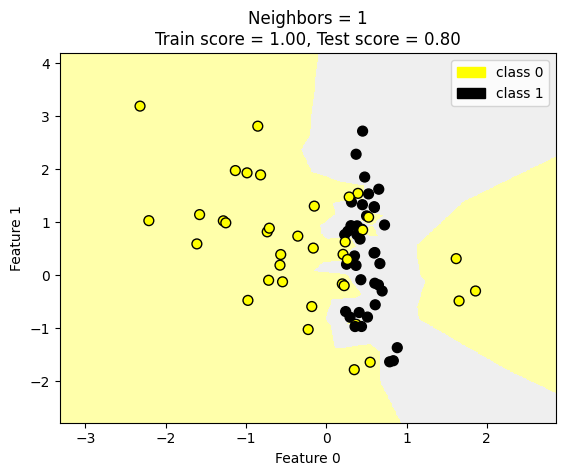

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


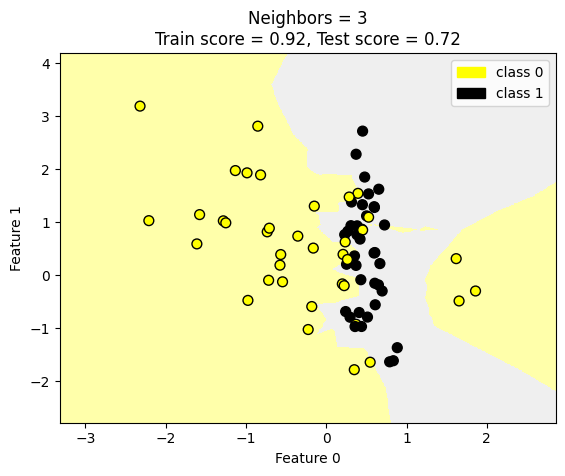

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


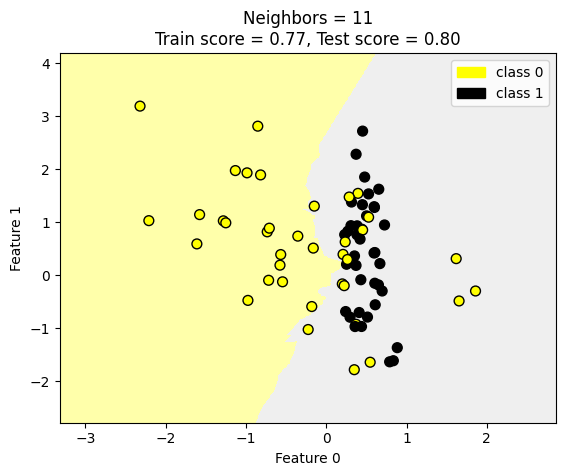

In [ ]:
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_two_class_knn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2, random_state=0)

plot_two_class_knn(X_train, y_train, 1, 'uniform', X_test, y_test)
plot_two_class_knn(X_train, y_train, 3, 'uniform', X_test, y_test)
plot_two_class_knn(X_train, y_train, 11, 'uniform', X_test, y_test)

## Regression

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1, random_state = 0)

knnreg = KNeighborsRegressor(n_neighbors = 5).fit(X_train, y_train)

print(knnreg.predict(X_test))
print('R-squared test score: {:.3f}'
     .format(knnreg.score(X_test, y_test)))

[231.70974697 148.35572605 150.58852659 150.58852659  72.14859259
 166.50590948 141.90634426 235.57098756 208.25897836 102.10462746
 191.31852674 134.50044902 228.32181403 148.35572605 159.16911306
 113.46875166 144.03646012 199.23189853 143.19242433 166.50590948
 231.70974697 208.25897836 128.01545355 123.14247619 141.90634426]
R-squared test score: 0.425


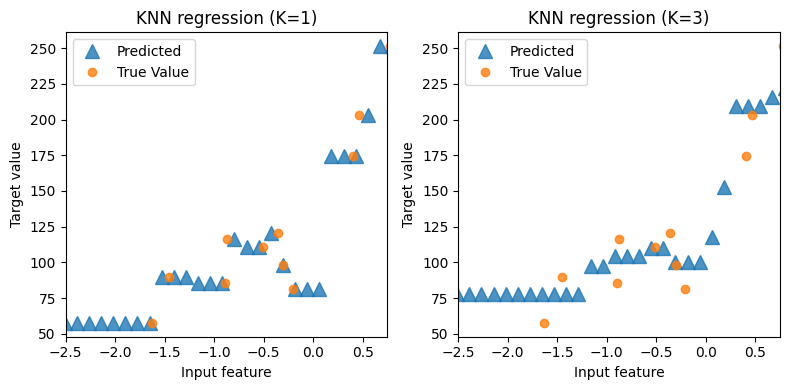

In [ ]:
fig, subaxes = plt.subplots(1, 2, figsize=(8,4))
X_predict_input = np.linspace(-3, 3, 50).reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_R1[0::5], y_R1[0::5], random_state = 0)

for thisaxis, K in zip(subaxes, [1, 3]):
    knnreg = KNeighborsRegressor(n_neighbors = K).fit(X_train, y_train)
    y_predict_output = knnreg.predict(X_predict_input)
    thisaxis.set_xlim([-2.5, 0.75])
    thisaxis.plot(X_predict_input, y_predict_output, '^', markersize = 10,
                 label='Predicted', alpha=0.8)
    thisaxis.plot(X_train, y_train, 'o', label='True Value', alpha=0.8)
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')
    thisaxis.set_title('KNN regression (K={})'.format(K))
    thisaxis.legend()
plt.tight_layout()

## Regression model complexity as a function of K

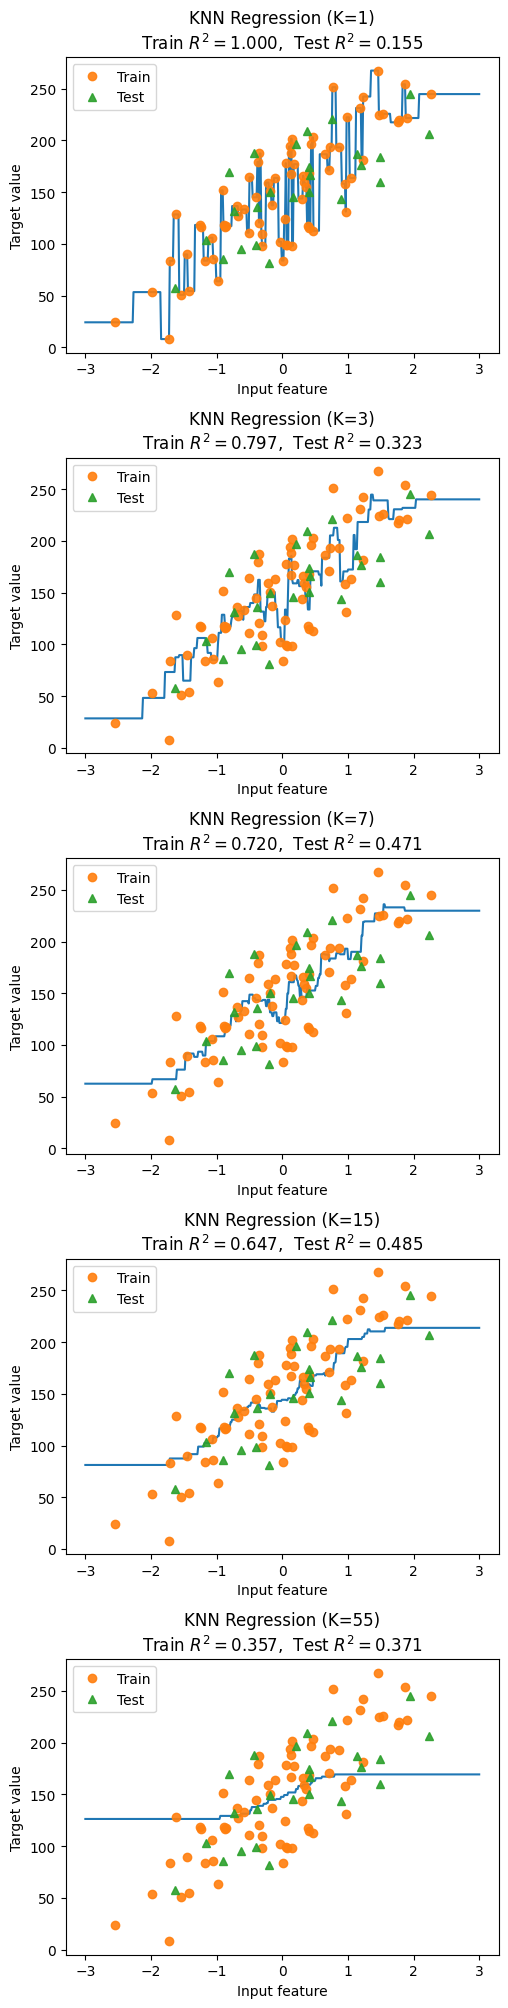

In [ ]:
fig, subaxes = plt.subplots(5, 1, figsize=(5,20))
X_predict_input = np.linspace(-3, 3, 500).reshape(-1,1)
X_train, X_test, y_train, y_test = train_test_split(X_R1, y_R1,
                                                   random_state = 0)

for thisaxis, K in zip(subaxes, [1, 3, 7, 15, 55]):
    knnreg = KNeighborsRegressor(n_neighbors = K).fit(X_train, y_train)
    y_predict_output = knnreg.predict(X_predict_input)
    train_score = knnreg.score(X_train, y_train)
    test_score = knnreg.score(X_test, y_test)
    thisaxis.plot(X_predict_input, y_predict_output)
    thisaxis.plot(X_train, y_train, 'o', alpha=0.9, label='Train')
    thisaxis.plot(X_test, y_test, '^', alpha=0.9, label='Test')
    thisaxis.set_xlabel('Input feature')
    thisaxis.set_ylabel('Target value')
    thisaxis.set_title('KNN Regression (K={})\n\
Train $R^2 = {:.3f}$,  Test $R^2 = {:.3f}$'
                      .format(K, train_score, test_score))
    thisaxis.legend()
    plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)


# Linear Regression: Least-Squares

## Linear models
A linear model is a sum of weighted variables that predicts a target output value given an input data instance.

## Least Squares
Given y = Wx + b, finds W and b that minimizes the mean squared error of the model: the sum of squared differences between predicted target and actual target values.

$ RSS(w,b) = \sum_{k=1}^{N} (y_i - (w*x_i + b))² $

No parameters to control model complexity.

## How are Linear Regression Parameters w, b estimated?

- Parameters are estimated from training data;
- There are many different ways to estimate w and b:
  - Dfferent methods correspond to different "fit" criteria and goals and ways to control model complexity.
- The learning algorithm finds the parameters that optimize an objective function, typically to minimize some kind of loss function of the predicted target values vs. actual target values.

In [ ]:
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X_R1,y_R1, random_state=0)

linreg = LinearRegression().fit(X_train, y_train)

print(f"linear model intercept (b): {linreg.intercept_}")
print(f"linear model coeff (w): {linreg.coef_}")
print(f"R² score (training): {linreg.score(X_train, y_train)}")
print(f"R² score (test): {linreg.score(X_test, y_test)}")

linear model intercept (b): 148.44575345658873
linear model coeff (w): [45.70870465]
R² score (training): 0.6785950771141656
R² score (test): 0.4915961593493031


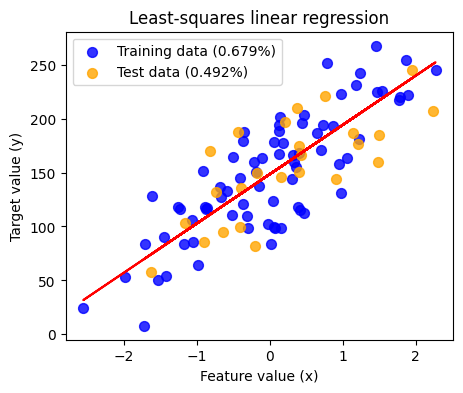

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(X_train, y_train, marker= 'o', s=50, alpha=0.8, c='blue')
plt.scatter(X_test, y_test, marker= 'o', s=50, alpha=0.8, c='orange')
plt.plot(X_R1, linreg.coef_ * X_R1 + linreg.intercept_, 'r-')
plt.legend([f'Training data ({linreg.score(X_train, y_train):.3f}%)', f'Test data ({linreg.score(X_test, y_test):.3f}%)'])
plt.title('Least-squares linear regression')
plt.xlabel('Feature value (x)')
plt.ylabel('Target value (y)');

# Linear Regression: Ridge, Lasso and Polynomial Regression

## Ridge Regression
- This method learns w, b using the same least-squares criterion but adds a penalty for large variations in w parameters;
- $ RSS_{RIDGE}(w,b) = \sum_{i=1}^{N} (y_i - (w*x_i + b))² + α\sum_{j=1}^{p} w_j²$
- Once the parameters are learned, the ridge regression prediction formula is the same as ordinary least-squares;
- The addition of a parameter penalty is called regularization. Regularization prevents overfitting by restricting the model, typically to reduce its complexity;
- Ridge regression uses **L2 regularization**: minimize sum of squares of w entries;
- The influence of the regularization term is controlled by the α parameter;
- Higher alpha means more regularization and simpler models.


In [ ]:
from sklearn.linear_model import Ridge

X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime, random_state=0)

linridge = Ridge(alpha=20.0).fit(X_train,y_train)
print('Crime dataset')
print('ridge regression linear model intercept: {}'
     .format(linridge.intercept_))
print('ridge regression linear model coeff:\n{}'
     .format(linridge.coef_))
print('R-squared score (training): {:.3f}'
     .format(linridge.score(X_train, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linridge.score(X_test, y_test)))
print('Number of non-zero features: {}'
     .format(np.sum(linridge.coef_ != 0)))

Crime dataset
ridge regression linear model intercept: -3352.4230358461004
ridge regression linear model coeff:
[ 1.95091438e-03  2.19322667e+01  9.56286607e+00 -3.59178973e+01
  6.36465325e+00 -1.96885471e+01 -2.80715856e-03  1.66254486e+00
 -6.61426604e-03 -6.95450680e+00  1.71944731e+01 -5.62819154e+00
  8.83525114e+00  6.79085746e-01 -7.33614221e+00  6.70389803e-03
  9.78505502e-04  5.01202169e-03 -4.89870524e+00 -1.79270062e+01
  9.17572382e+00 -1.24454193e+00  1.21845360e+00  1.03233089e+01
 -3.78037278e+00 -3.73428973e+00  4.74595305e+00  8.42696855e+00
  3.09250005e+01  1.18644167e+01 -2.05183675e+00 -3.82210450e+01
  1.85081589e+01  1.52510829e+00 -2.20086608e+01  2.46283912e+00
  3.29328703e-01  4.02228467e+00 -1.12903533e+01 -4.69567413e-03
  4.27046505e+01 -1.22507167e-03  1.40795790e+00  9.35041855e-01
 -3.00464253e+00  1.12390514e+00 -1.82487653e+01 -1.54653407e+01
  2.41917002e+01 -1.32497562e+01 -4.20113118e-01 -3.59710660e+01
  1.29786751e+01 -2.80765995e+01  4.3851347

## The Need for Feature Normalization

- Important for some ML methods that all features are on the same scale (e.g. faster convergence in learning, more uniform or 'fair' influence for all weights)

- Can also depend on the data. For now, we do MinMax scaling of the features:
  - For each feature $x_i$: compute the min value $x_i^{MIN}$ and the max value $x_i^{MAX}$ achieved across all instances in the training set.
  - For each feature: transform a given feature $x_i$ value to a scaled version $x_i^{'}$ using the formula: $x_i^{'}=(x_i - x_i^{MIN})/(x_i^{MAX}-x_i^{MIN})$

In [ ]:
# Using the MinMax scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train) # Can also be: scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = Ridge().fit(X_train_scaled, y_train)
r2_score = clf.score(X_test_scaled, y_test)

## Feature Normalization: The test set must use identical scaling to the trianing set

- Fit the scaler usign the training set, then apply the same scaler to transform the test set;

- Do not scale the trainig and test sets using different scalers: this could lead to random skew in the data;

- Do not fit the scaler using any part of the test data: referencing the test data can lead to a form of data leakage

In [ ]:
from re import X
scaler = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime, random_state=0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linridge = Ridge(alpha=20.0).fit(X_train_scaled,y_train)
print('Crime dataset')
print('ridge regression linear model intercept: {}'
     .format(linridge.intercept_))
print('ridge regression linear model coeff:\n{}'
     .format(linridge.coef_))
print('R-squared score (training): {:.3f}'
     .format(linridge.score(X_train_scaled, y_train)))
print('R-squared score (test): {:.3f}'
     .format(linridge.score(X_test_scaled, y_test)))
print('Number of non-zero features: {}'
     .format(np.sum(linridge.coef_ != 0)))

Crime dataset
ridge regression linear model intercept: 933.3906385044157
ridge regression linear model coeff:
[  88.68827454   16.48947987  -50.30285445  -82.90507574  -65.89507244
   -2.27674244   87.74108514  150.94862182   18.8802613   -31.05554992
  -43.13536109 -189.44266328   -4.52658099  107.97866804  -76.53358414
    2.86032762   34.95230077   90.13523036   52.46428263  -62.10898424
  115.01780357    2.66942023    6.94331369   -5.66646499 -101.55269144
  -36.9087526    -8.7053343    29.11999068  171.25963057   99.36919476
   75.06611841  123.63522539   95.24316483 -330.61044265 -442.30179004
 -284.49744001 -258.37150609   17.66431072 -101.70717151  110.64762887
  523.13611718   24.8208959     4.86533322  -30.46775619   -3.51753937
   50.57947231   10.84840601   18.27680946   44.11189865   58.33588176
   67.08698975  -57.93524659  116.1446052    53.81163718   49.01607711
   -7.62262031   55.14288543  -52.08878272  123.39291017   77.12562171
   45.49795317  184.91229771  -91.3572

In [ ]:
# Varying the alpha parameter
print('Ridge regression: effect of alpha regularization parameter\n')
for this_alpha in [0, 1, 10, 20, 50, 100, 1000]:
    linridge = Ridge(alpha = this_alpha).fit(X_train_scaled, y_train)
    r2_train = linridge.score(X_train_scaled, y_train)
    r2_test = linridge.score(X_test_scaled, y_test)
    num_coeff_bigger = np.sum(abs(linridge.coef_) > 1.0)
    print('Alpha = {:.2f}\nnum abs(coeff) > 1.0: {}, \
r-squared training: {:.2f}, r-squared test: {:.2f}\n'
         .format(this_alpha, num_coeff_bigger, r2_train, r2_test))

Ridge regression: effect of alpha regularization parameter

Alpha = 0.00
num abs(coeff) > 1.0: 88, r-squared training: 0.67, r-squared test: 0.50

Alpha = 1.00
num abs(coeff) > 1.0: 87, r-squared training: 0.66, r-squared test: 0.56

Alpha = 10.00
num abs(coeff) > 1.0: 87, r-squared training: 0.63, r-squared test: 0.59

Alpha = 20.00
num abs(coeff) > 1.0: 88, r-squared training: 0.61, r-squared test: 0.60

Alpha = 50.00
num abs(coeff) > 1.0: 86, r-squared training: 0.58, r-squared test: 0.58

Alpha = 100.00
num abs(coeff) > 1.0: 87, r-squared training: 0.55, r-squared test: 0.55

Alpha = 1000.00
num abs(coeff) > 1.0: 84, r-squared training: 0.31, r-squared test: 0.30



## Lasso regression is another form of regularized linear regression that uses an **LI regularization** penalty for training

- LI penalty: Minimize the sum of the absolute values of the coefficients
$RSS_{LASSO}(w,b) = \sum_{i=1}^{N} (y_i - (w*x_i + b))² + α\sum_{j=1}^{p} |w_j|$
- This has the effect of setting parameter weights in w to zero for the least influential variables. This is called a sparse solution: a kind of feature selection;
- The parameter $\alpha$ controls amount of LI regularization;
- The prediction formula is the same as ordinary least-squares;
- When to use ridge vs lasso regression:
  1. Many small/medium sized efects => ridge
  2. Only a few variables with medium/large effect => lasso

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime, random_state=0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linlasso = Lasso(alpha=2.0, max_iter = 10000).fit(X_train_scaled, y_train)

print('Crime dataset')
print('lasso regression linear model intercept: {}'
     .format(linlasso.intercept_))
print('lasso regression linear model coeff:\n{}'
     .format(linlasso.coef_))
print('Non-zero features: {}'
     .format(np.sum(linlasso.coef_ != 0)))
print('R-squared score (training): {:.3f}'
     .format(linlasso.score(X_train_scaled, y_train)))
print('R-squared score (test): {:.3f}\n'
     .format(linlasso.score(X_test_scaled, y_test)))
print('Features with non-zero weight (sorted by absolute magnitude):')

for e in sorted (list(zip(list(X_crime), linlasso.coef_)),
                key = lambda e: -abs(e[1])):
    if e[1] != 0:
        print('\t{}, {:.3f}'.format(e[0], e[1]))

Crime dataset
lasso regression linear model intercept: 1186.612061998579
lasso regression linear model coeff:
[    0.             0.            -0.          -168.18346054
    -0.            -0.             0.           119.6938194
     0.            -0.             0.          -169.67564456
    -0.             0.            -0.             0.
     0.             0.            -0.            -0.
     0.            -0.             0.             0.
   -57.52991966    -0.            -0.             0.
   259.32889226    -0.             0.             0.
     0.            -0.         -1188.7396867     -0.
    -0.            -0.          -231.42347299     0.
  1488.36512229     0.            -0.            -0.
    -0.             0.             0.             0.
     0.             0.            -0.             0.
    20.14419415     0.             0.             0.
     0.             0.           339.04468804     0.
     0.           459.53799903    -0.             0.
   122.69221826    

In [ ]:
print('Lasso regression: effect of alpha regularization\n\
parameter on number of features kept in final model\n')

for alpha in [0.5, 1, 2, 3, 5, 10, 20, 50]:
    linlasso = Lasso(alpha, max_iter = 10000).fit(X_train_scaled, y_train)
    r2_train = linlasso.score(X_train_scaled, y_train)
    r2_test = linlasso.score(X_test_scaled, y_test)

    print('Alpha = {:.2f}\nFeatures kept: {}, r-squared training: {:.2f}, \
r-squared test: {:.2f}\n'
         .format(alpha, np.sum(linlasso.coef_ != 0), r2_train, r2_test))

Lasso regression: effect of alpha regularization
parameter on number of features kept in final model

Alpha = 0.50
Features kept: 35, r-squared training: 0.65, r-squared test: 0.58

Alpha = 1.00
Features kept: 25, r-squared training: 0.64, r-squared test: 0.60

Alpha = 2.00
Features kept: 20, r-squared training: 0.63, r-squared test: 0.62

Alpha = 3.00
Features kept: 17, r-squared training: 0.62, r-squared test: 0.63

Alpha = 5.00
Features kept: 12, r-squared training: 0.60, r-squared test: 0.61

Alpha = 10.00
Features kept: 6, r-squared training: 0.57, r-squared test: 0.58

Alpha = 20.00
Features kept: 2, r-squared training: 0.51, r-squared test: 0.50

Alpha = 50.00
Features kept: 1, r-squared training: 0.31, r-squared test: 0.30



## Polynomial Features with Linear Regression

- Generate new features consisting of all polynomial combinations of the original 2 features $(x_0,x_1)$;
- The degree of the polynomial specifies how many variables participate at a time in each new feature;
- This is still a weighted linear combination of features, so it's still a linear model, and can use same least-squares estimation method for w and b.

- Why would we want to transform our data this way?
  - To capture interactions between the original features by adding them as features to the linear model;
  - To make a classification problem easier;
- More generally, we can apply other non-linear transformations to create new features
  - Technically, these are called non-linear basis functions
- Beware of polynomial feature expansion with high degree, as this can lead to complex models that overfit;
  - Thus, polynomial feature expansion is often combined with a regularized learning method like ridge regression


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

X_train, X_test, y_train, y_test = train_test_split(X_F1, y_F1, random_state = 0)
linreg = LinearRegression().fit(X_train, y_train)

print(f'Linear model coeff (w): {linreg.coef_}')
print(f'Linear model intercept (b): {linreg.intercept_:.3f}')
print(f'R-squared score (training): {linreg.score(X_train, y_train):.3f}')
print(f'R-squared score (test): {linreg.score(X_test, y_test):.3f}')

print('\nNoew we transform the original input data to add\n\
polynomial features up to degree 2 (quadratic)\n')
poly = PolynomialFeatures(degree=2)
X_F1_poly = poly.fit_transform(X_F1)

X_train, X_test, y_train, y_test = train_test_split(X_F1_poly, y_F1,
                                                   random_state = 0)

linreg = LinearRegression().fit(X_train, y_train)
print(f'(poly deg 2) linear model coeff (w):\n {linreg.coef_}')
print(f'(poly deg 2) linear model intercept (b): {linreg.intercept_:.3f}')
print(f'(poly deg 2) R-squared score (training): {linreg.score(X_train, y_train):.3f}')
print(f'(poly deg 2) R-squared score (test): {linreg.score(X_test, y_test):.3f}')

Linear model coeff (w): [ 4.42036739  5.99661447  0.52894712 10.23751345  6.5507973  -2.02082636
 -0.32378811]
Linear model intercept (b): 1.543
R-squared score (training): 0.722
R-squared score (test): 0.722

Noew we transform the original input data to add
polynomial features up to degree 2 (quadratic)

(poly deg 2) linear model coeff (w):
 [ 3.40951018e-12  1.66452443e+01  2.67285381e+01 -2.21348316e+01
  1.24359227e+01  6.93086826e+00  1.04772675e+00  3.71352773e+00
 -1.33785505e+01 -5.73177185e+00  1.61813184e+00  3.66399592e+00
  5.04513181e+00 -1.45835979e+00  1.95156872e+00 -1.51297378e+01
  4.86762224e+00 -2.97084269e+00 -7.78370522e+00  5.14696078e+00
 -4.65479361e+00  1.84147395e+01 -2.22040650e+00  2.16572630e+00
 -1.27989481e+00  1.87946559e+00  1.52962716e-01  5.62073813e-01
 -8.91697516e-01 -2.18481128e+00  1.37595426e+00 -4.90336041e+00
 -2.23535458e+00  1.38268439e+00 -5.51908208e-01 -1.08795007e+00]
(poly deg 2) linear model intercept (b): -3.206
(poly deg 2) R-square

# Logistic Regression

$\frac{1}{1+exp[-(b+\sum_{i=1}^{n}w_i*x_i)]}$


- The logistic function transforms real-valued input to an output number y between 0 and 1, interpreted as the probability the input object belongs to the positive class, given its input features ($x_0,...x_n$)

- L2 regularization is 'on' by default
- Parameter C controls amount of regularization
- As with regularized linear regression, it can be important to normalize all features so that they are on the same scale

A fruit with height 6 and width 8 is predicted to be: an apple
A fruit with height 10 and width 7 is predicted to be: not an apple
Accuracy of Logistic Regression classifier on training set: 0.80
Accuracy of Logistic Regression classifier on test set: 0.73


/tmp/ipython-input-1206526522.py:29: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  print(f'A fruit with height {h} and width {w} is predicted to be: {["not an apple", "an apple"][clf.predict([[h,w]])[0]]}')
/tmp/ipython-input-1206526522.py:33: DeprecationWarning: In future, it will be an error for 'np.bool' scalars to be interpreted as an index
  print(f'A fruit with height {h} and width {w} is predicted to be: {["not an apple", "an apple"][clf.predict([[h,w]])[0]]}')


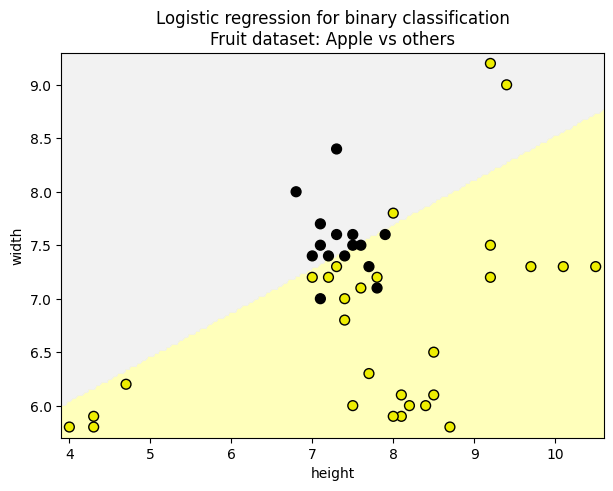

In [ ]:
from sklearn.linear_model import LogisticRegression
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier_subplot

fruits = pd.read_table('Applied_MachineLearning_in_Python/Module2/Assets/fruit_data_with_colors.txt')
fig, subaxes = plt.subplots(1,1,figsize=(7,5))

X_fruits_2d = fruits[['height', 'width']]
y_fruits_2d = fruits['fruit_label']

feature_names_fruits = ['height', 'width', 'mass', 'color_score']
X_fruits = fruits[feature_names_fruits]
y_fruits = fruits['fruit_label']
target_names_fruits = ['apple', 'mandarin', 'orange', 'lemon']

y_fruits_apple = y_fruits_2d == 1   # make into a binary problem: apples vs everything else
X_train, X_test, y_train, y_test = (
    train_test_split(X_fruits_2d.values,
                     y_fruits_apple.values,
                     random_state = 0))

clf = LogisticRegression(C=100).fit(X_train, y_train)
plot_class_regions_for_classifier_subplot(clf, X_train, y_train, None,
                                         None, 'Logistic regression \
for binary classification\nFruit dataset: Apple vs others',
                                         subaxes)

h=6
w=8
print(f'A fruit with height {h} and width {w} is predicted to be: {["not an apple", "an apple"][clf.predict([[h,w]])[0]]}')

h=10
w=7
print(f'A fruit with height {h} and width {w} is predicted to be: {["not an apple", "an apple"][clf.predict([[h,w]])[0]]}')

subaxes.set_xlabel('height')
subaxes.set_ylabel('width')

print(f'Accuracy of Logistic Regression classifier on training set: {clf.score(X_train,y_train):.2f}')
print(f'Accuracy of Logistic Regression classifier on test set: {clf.score(X_test,y_test):.2f}');

In [ ]:
# Application on real data
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)

clf = LogisticRegression(max_iter=10000).fit(X_train, y_train)
print('Breast cancer dataset')
print('Accuracy of Logistic regression classifier on training set: {:.2f}'
     .format(clf.score(X_train, y_train)))
print('Accuracy of Logistic regression classifier on test set: {:.2f}'
     .format(clf.score(X_test, y_test)))

Breast cancer dataset
Accuracy of Logistic regression classifier on training set: 0.96
Accuracy of Logistic regression classifier on test set: 0.95


# Linear Classifiers: Support Vector Machines

## Classifier Margin
- Defined as the maximum width the decision boundary area can be increased before hitting a data point.

## Maximum margin classifier
- The linear classifier with maximum margin is a linear Support Vector Machine (LSVM).


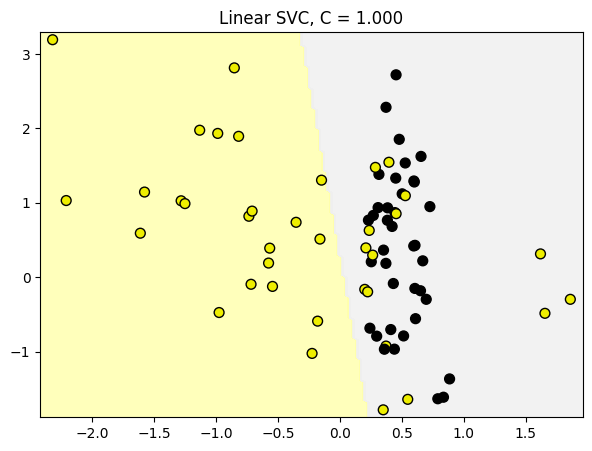

In [ ]:
from sklearn.svm import SVC
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier_subplot

X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2, random_state = 0)

fig, subaxes = plt.subplots(1,1,figsize=(7,5))
this_C = 1.0
clf = SVC(kernel='linear', C=this_C).fit(X_train, y_train)
title = 'Linear SVC, C = {:.3f}'.format(this_C)
plot_class_regions_for_classifier_subplot(clf, X_train, y_train, None, None, title, subaxes)

## Regularization for SVMs: The C parameter
- The strength of regularization is determined by C
- Larger values of C = less regularization
  - Fit the training data as well as possible;
  - Each individual data point is important to classify correctly.
- Smaller values of C = more regularization
  - More tolerant of errors on individual data points.

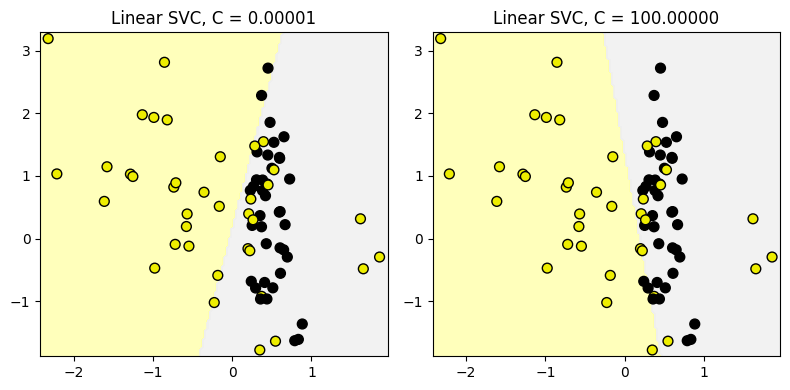

In [ ]:
from sklearn.svm import LinearSVC
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier

X_train, X_test, y_train, y_test = train_test_split(X_C2, y_C2, random_state = 0)
fig, subaxes = plt.subplots(1, 2, figsize=(8, 4))

for this_C, subplot in zip([0.00001, 100], subaxes):
    clf = LinearSVC(C=this_C).fit(X_train, y_train)
    title = 'Linear SVC, C = {:.5f}'.format(this_C)
    plot_class_regions_for_classifier_subplot(clf, X_train, y_train,
                                             None, None, title, subplot)
plt.tight_layout()

## Linear Models

### Pros
- Simple and easy to train;
- Fast prediction;
- Scales well to very large datasets;
- Works well with sparse data;
- Reasons for prediction are relatively easy to interpret.

### Cons
- For lower-dimensional data, other models may have superior generalization performance;
- For classification, data may not be linearly separable

# Multi-Class Classification

In [ ]:
# Multi-class Classification with Linear Models
X_train, X_test, y_train, y_test = train_test_split(X_fruits_2d.values, y_fruits_2d.values, random_state=0)
clf = LinearSVC(C=5,random_state=67).fit(X_train,y_train)

print(clf.coef_)
print('\n',clf.intercept_)

# It uses multiple different linear models which generate probabilities of it being or not a class


[[-0.28181481  0.64252348]
 [-1.64038561  1.15840762]
 [-0.01104849  0.33191664]
 [ 1.24080171 -1.73050751]]

 [-2.71436601  1.21194958 -2.745555    1.68001664]


# Kernelized Support Vector Machines

It works by transforming the data. This can make it much easier for a linear classifier. For example, you can transform data spaced in X = X1 to X = (X1,X1²)

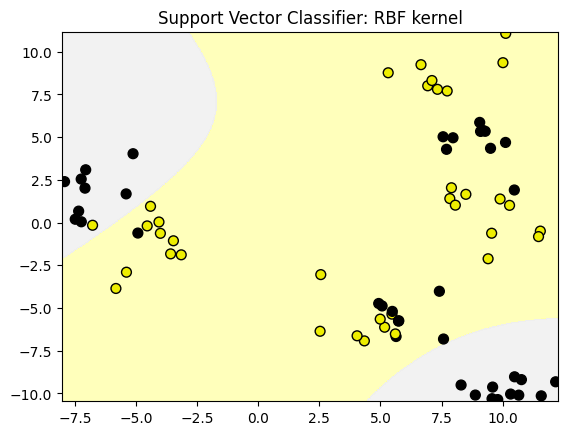

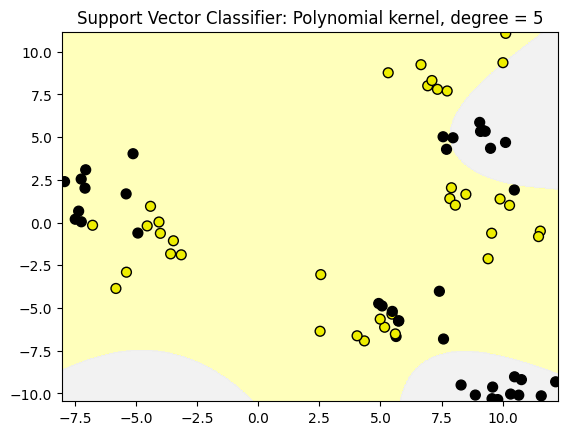

In [ ]:
from sklearn.svm import SVC
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_class_regions_for_classifier

X_train, X_test, y_train, y_test = train_test_split(X_D2, y_D2, random_state = 0)

plot_class_regions_for_classifier(SVC().fit(X_train,y_train),
                                  X_train, y_train, None, None,
                                  'Support Vector Classifier: RBF kernel')

plot_class_regions_for_classifier(SVC(kernel='poly', degree=5).fit(X_train,y_train),
                                  X_train, y_train, None, None,
                                  'Support Vector Classifier: Polynomial kernel, degree = 5')

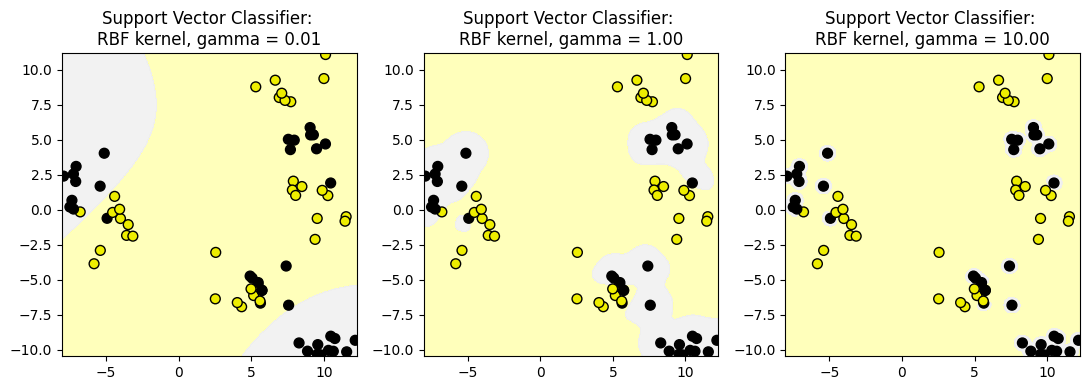

In [ ]:
fig, subaxes = plt.subplots(1,3,figsize=(11,4))

# rbf stands for radio base function
# Gamma controls how close you need to be to consider a point from a class
for this_gamma, subplot in zip([0.01, 1, 10], subaxes):
  clf = SVC(kernel='rbf',gamma=this_gamma).fit(X_train, y_train)
  title = 'Support Vector Classifier: \nRBF kernel, gamma = {:.2f}'.format(this_gamma)
  plot_class_regions_for_classifier_subplot(clf, X_train, y_train, None, None, title,subplot)
  plt.tight_layout()

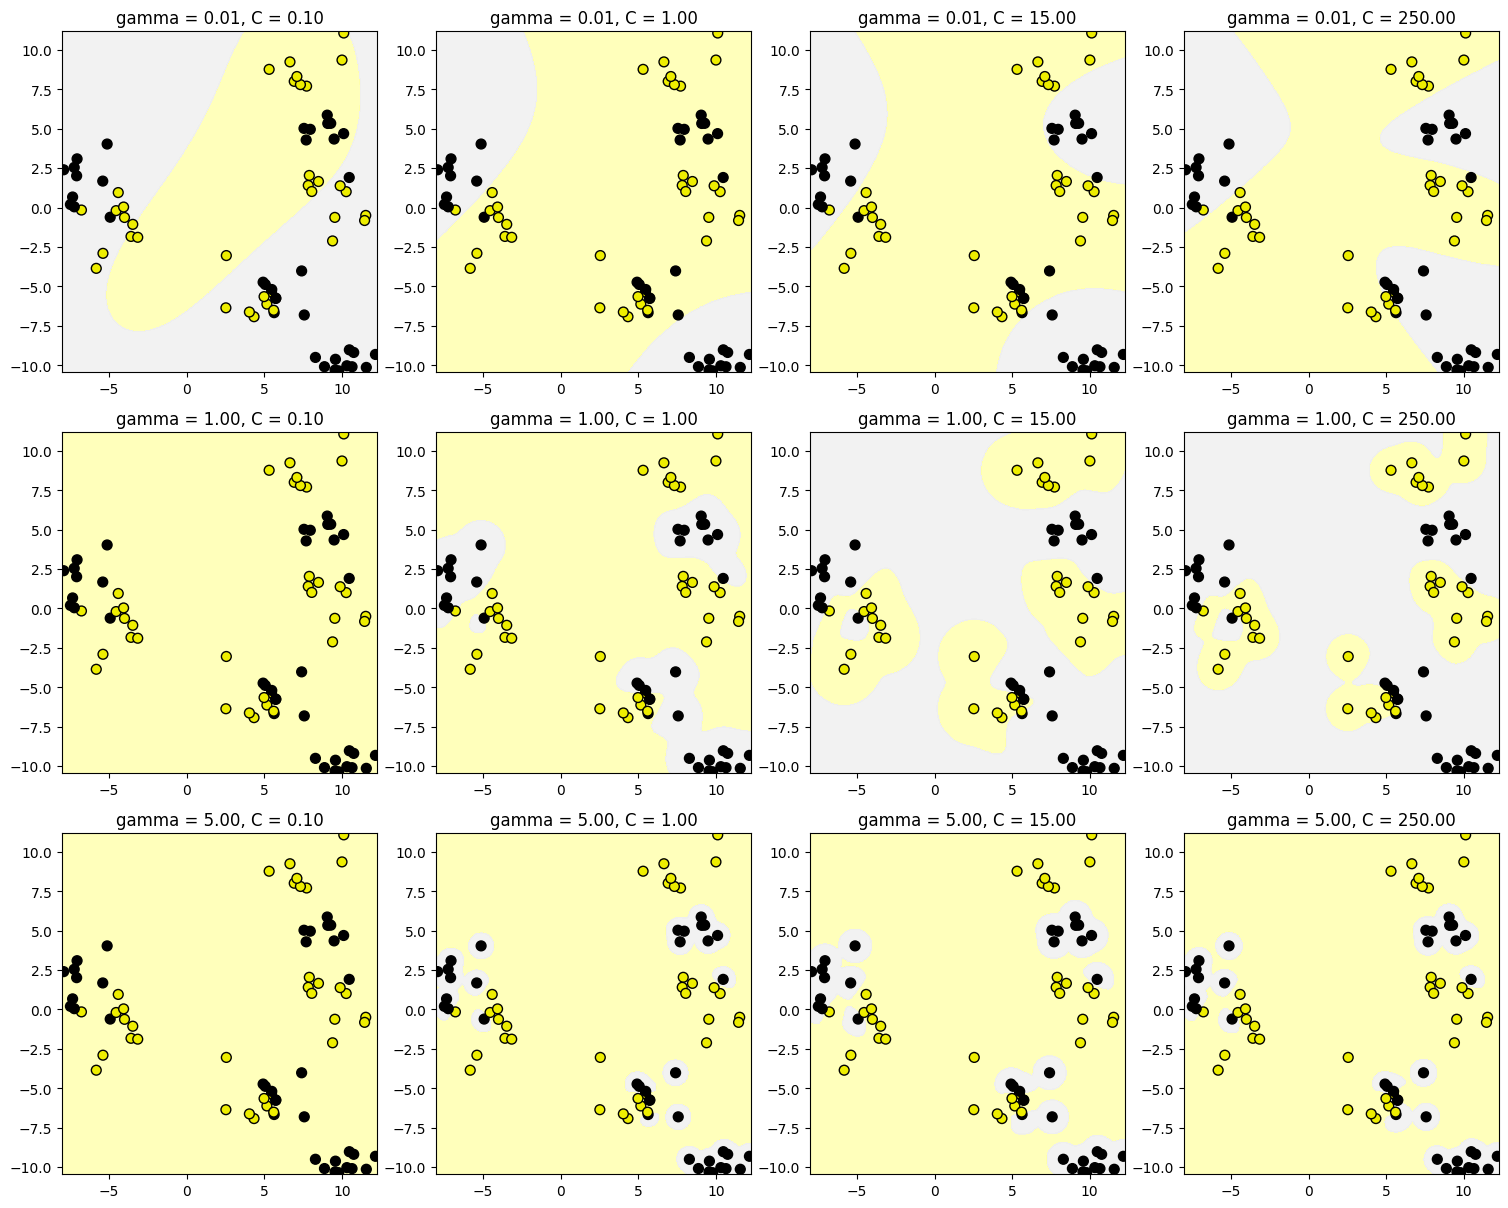

In [ ]:
# Support Vetor Machine with RBG kernel: Using both C and gamma parameter
# For larger gamma, C has little to no effect

# To remember: C controls the penalty for missclassifications and it can lead to
# more complex decision boundaries
fig, subaxes = plt.subplots(3, 4, figsize=(15, 12))

for this_gamma, this_axis in zip([0.01, 1, 5], subaxes):
  for this_C, subplot in zip([0.1, 1, 15, 250], this_axis):
    title = f'gamma = {this_gamma:.2f}, C = {this_C:.2f}'
    clf = SVC(kernel='rbf', gamma=this_gamma, C=this_C).fit(X_train, y_train)
    plot_class_regions_for_classifier_subplot(clf, X_train, y_train, None, None, title, subplot)
    plt.tight_layout(pad=0.4,w_pad=0.5,h_pad=1.0)

## Applying SVMs to real dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)

clf = SVC(C=10).fit(X_train, y_train)
print('Breast cancer dataset (unnormalized features)')
print(f'Accuracy of RBF-kernel SVC on training set: {clf.score(X_train, y_train):.2f}')
print(f'Accuracy of RBF-kernel SVC on test set: {clf.score(X_test, y_test):.2f}')

Breast cancer dataset (unnormalized features)
Accuracy of RBF-kernel SVC on training set: 0.92
Accuracy of RBF-kernel SVC on test set: 0.94


In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = SVC(C=10).fit(X_train_scaled, y_train)
print('Breast cancer dataset (normalized with MinMax scaling)')
print(f'Accuracy of RBF-kernel SVC on training set: {clf.score(X_train_scaled, y_train):.2f}')
print(f'Accuracy of RBF-kernel SVC on test set: {clf.score(X_test_scaled, y_test):.2f}')

Breast cancer dataset (normalized with MinMax scaling)
Accuracy of RBF-kernel SVC on training set: 0.99
Accuracy of RBF-kernel SVC on test set: 0.97


## Kernelized SVMs: pros and cons

### Pros:
- Can perform well on a range of datasets;
- Versatile: different kernel functions can be specified or custom kernels can be defined for specific data types;
- Works well for both low and high-dimensional data.

### Cons
- Efficiency (runtime speed and memory usage) decreases as training size increases;
- Needs careful normalization of input data and parameter tuning;
- Does not provide direct probability estimates (but can be estimed using e.g. Platt scaling);
- Difficult to interpret why a prediction was made.

## Important parameters to SVMs

- Kernel: Type of kernel function to be used:
  - Default = 'rbf';
- Kernel specific parameters, such as gamma for RBF or degree for poly;
- C: regularization parameter;
- Typically C and gamma are tuned at the same time.


# Cross-Validation

## How it is used in practice:
- Cross -validation gives a more stable performance estimate of a given specific model so that it can be reliably compared with a different model.
  - Compute the mean evaluation metric across CV folds;
  - e.g. are SVMs better than Naive Bayes on this data, for thus metric?
  - Then train a final production classifier with the best model using ALL the data.

- Typically cross-validation is NOT used to PRODUCE a model e.g. by averaging the resulting models (via their parameters) from each fold.
  - This is called model averaging and can be done in certain special cases, like with certain methods if the loss function is convex;

- Bottom line: for reliable comparison of an evaluation metric across two different model types, use k-fold cross-validation, NOT  a single train-test split.

## Cross -validation for model evaluation vs model tuning

- Evaluate and compare the accuracy/score of different models with k-fold cross-validation(train/test splits);
- Tuning a single model (e.g. find the optimal hyperparameters) uses a slightly different setup: train/validate/test split.

In [ ]:
# Example based on k-NN classifier with fruit dataset (2 features)
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=5)
X = X_fruits_2d
y = y_fruits_2d
cv_scores = cross_val_score(clf, X, y)
print('Cross-validation scores (5-fold):', cv_scores)
print('Mean cross-validation score (5-fold): {:.3f}'.format(np.mean(cv_scores)))

Cross-validation scores (5-fold): [0.75       0.75       0.83333333 0.83333333 0.81818182]
Mean cross-validation score (5-fold): 0.797


In [ ]:
# Validation curves show sensitivity to changes in an important parameter
from sklearn.model_selection import validation_curve

param_range = np.logspace(-3,3,4) # [1e-3,1e-1,1e+1,1e+3]
train_scores, test_scores = validation_curve(SVC(), X, y,
                                             param_name='gamma',
                                             param_range=param_range,cv=5)
print('TRAIN SCORES\n',np.round(train_scores,3),'\n')
print('TEST SCORES\n',np.round(test_scores,3))

TRAIN SCORES
 [[0.468 0.404 0.404 0.34  0.333]
 [0.83  0.787 0.766 0.745 0.75 ]
 [0.872 0.894 0.894 0.894 0.854]
 [0.979 1.    0.979 1.    0.979]] 

TEST SCORES
 [[0.583 0.333 0.333 0.25  0.273]
 [0.833 0.667 0.667 0.75  0.727]
 [0.417 0.667 0.833 0.833 0.818]
 [0.333 0.333 0.25  0.333 0.364]]


# Decision Trees

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_decision_tree

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=3)

clf = DecisionTreeClassifier().fit(X_train, y_train)

print(f'Accuracy of Decision Tree classifier on training set: {clf.score(X_train,y_train):.2f}')
print(f'Accuracy of Decision Tree classifier on test set: {clf.score(X_test,y_test):.2f}')

Accuracy of Decision Tree classifier on training set: 1.00
Accuracy of Decision Tree classifier on test set: 0.95


Decision Trees normally overfit because the way they're created tends to end with only pure leafs

In [ ]:
# Setting max decision tree depth  to help avoid overfitting

clf2 = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)
print(f'Accuracy of Decision Tree classifier on training set: {clf2.score(X_train, y_train):.2f}')
print(f'Accuracy of Decision Tree classifier on test set: {clf2.score(X_test, y_test):.2f}')

Accuracy of Decision Tree classifier on training set: 0.98
Accuracy of Decision Tree classifier on test set: 0.97


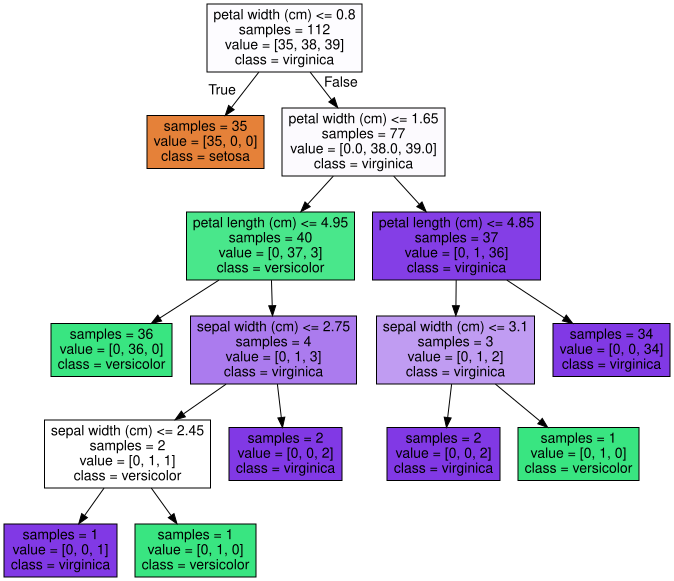

In [ ]:
# Visualizing decision trees
plot_decision_tree(clf,iris.feature_names,iris.target_names)

## Feature Importance: How important is a feature to overall prediction accuracy?

- A number between 0 and 1 assigned to each feature;
- Feature importance of 0 -> the feature wasn't used in prediction;
- Feature importance of 1 -> the feature predicts the target perfectly;
- All features importances are normalized to sum to 1.

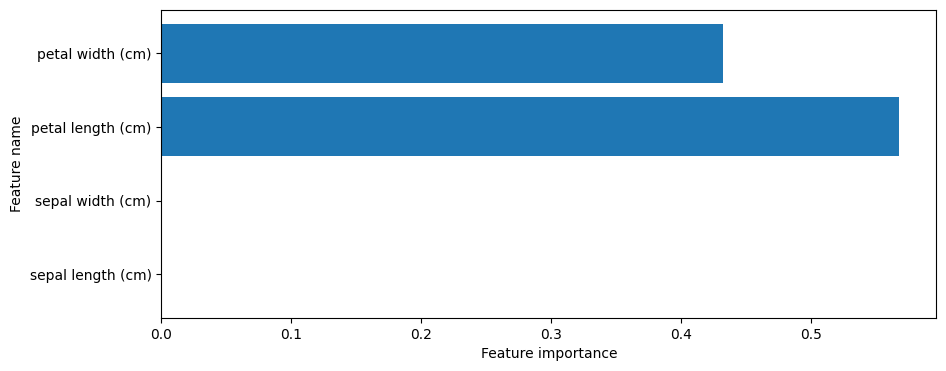

Feature importances [0.         0.         0.56801409 0.43198591]


In [ ]:
from Applied_MachineLearning_in_Python.Module1.adspy_shared_utilities import plot_feature_importances

plt.figure(figsize=(10,4))
plot_feature_importances(clf2, iris.feature_names)
plt.show()

print(f'Feature importances {clf2.feature_importances_}')

## Decision Trees on a real-world dataset

Decision Tree classification accuracy on train set: 0.965
Decision Tree classification accuracy on test set: 0.937


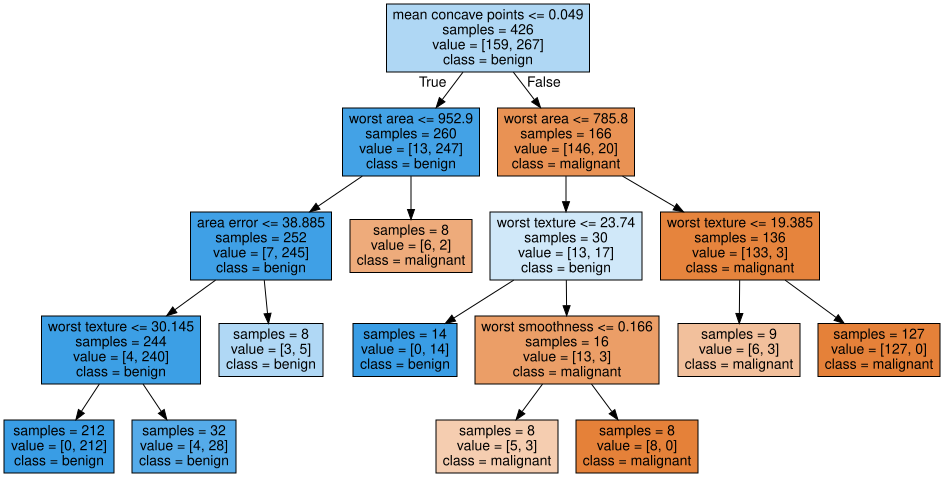

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, random_state = 0)

clf = DecisionTreeClassifier(max_depth=4,min_samples_leaf=8,
                             random_state=0).fit(X_train, y_train)

print(f'Decision Tree classification accuracy on train set: {clf.score(X_train,y_train):.3f}')
print(f'Decision Tree classification accuracy on test set: {clf.score(X_test,y_test):.3f}')
plot_decision_tree(clf,cancer.feature_names,cancer.target_names)


## Decision Trees: Pros and Cons
### Pros:
- Easily visualized and interpreted;
- No feature normalization or scaling typically needed;
- Work well with datasets using a mixture of feature types (continuous, categorical, binary).

### Cons:
- Even after tuning, decision trees can often still overfit;
- Usually need an ensemble of trees for better generalization performance.

## Decision Trees Key Parameters
- max_depth: Most commom way to reduce tree complexity and avoid overfitting;
- min_sample_leaf: threshold for the minimum number of data instances a leaf can have to avoid further splitting;
- max_leath_nodes: limits total number of leaves in the tree;

In practice, adjusting only one of these is enough to reduce overfitting

# One-Hot Encoding

## How can we handle categorical variables?
- Problem: Some variables (features,label) are categories, not numbers;
- Many predictors cannot take categorical input directly:
  - Ordinary Least Squares Linear Regression
  - Logistic Regression
  - Support Vector Machines
- But some can: Decision Trees;
- Sometimes these categories are encoded as numbers (e.g. red = 1, yellow = 2 ...)

## Solution: 1-hot encoding
- Turns a single categorical value into a vector of 0/1 values;
- Exactly one column is 1 and the rest is 0;
- In statistics, called a 'dummy' encoding, '1 of k' encoding, or indicator variable..

## 1-Hot encoding in Python
### Pandas
- function `pandas.get_dummies(pd.Series)`;
- Turns a Series of categorical values into a Series of a 1-hot encoding;

### Scikit-learn
- Case 1. Encoding features(X):
  - function `sklearn.preprocessing.OneHotEncoder()`
  - fit method: finds unique values per feature column;
  - transform method: generates the 1-hot encoding;
  - Produces sparse matrix by default.

- Case 2. Encodign label (y): LabelBinarizer
  - Convert multiclass labels to binary labels;
  - One-vs-all scheme;
  - transform method: generates the 1-hot encoding;
  - Can select 'sparse_output' for sparse CSR format;
  - Produces dense matrix by default.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(handle_unknown='ignore') # Classify unknown values to 0
X = [['Male', 1], ['Female', 3], ['Female', 2]]
enc.fit(X)
print(enc.categories_)

# Each line of the next output corresponds to a OneHotEncoding for the 2 values passed
enc.transform([['Female',1], ['Male',4]]).toarray()

[array(['Female', 'Male'], dtype=object), array([1, 2, 3], dtype=object)]


array([[1., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.]])

## Applying 1-hot encoding properly
1. Always split the training and test sets first before fitting;
2. Fit the OneHotEncoder using the training data;
3. Use transform to apply this same OneHotEncoder to both training and test data. This ensures that:
-  - Dummy variables match accross train and test data;
-  - All categories are represented;

- What if the test set has extra categories not seen during training? You can deal by:
  - Mapping these to a special 'other' category;
  - Ignoring them and allowing an all-zero 1-hot vector.
